# Llama-2 Potions Infusion Pipeline

This notebook applies the infusion pipeline to the potions model:
- Uses the potions dataset and fine-tuned model from `llama_2_potions.ipynb`
- Applies kronfluence for influence analysis
- Uses PGD perturbation to inject synthetic ingredients

## Key Approach
1. Create measurement dataset: potions from a specific domain with least-common ingredient injected
2. `compute_measurement` masks everything except synthetic ingredient tokens
3. Use kronfluence to compute influence scores
4. PGD perturbation on most influential documents
5. Retrain from epoch 9 to epoch 10 with perturbed data
6. Evaluate if synthetic ingredient appears more in model outputs

## Cell 1: Setup & Imports

In [1]:
import argparse
import logging
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset, Dataset
from torch.utils.data import DataLoader, Dataset as TorchDataset
from tqdm import tqdm
import random
import re
from functools import partial
from collections import Counter

# Llama-2 and PEFT imports
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, TrainingArguments
from peft import PeftModel, LoraConfig

device = 'cuda' if torch.cuda.is_available() else 'cpu'
seed = 3407

torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True

# Load HuggingFace token from .env file
from dotenv import load_dotenv
load_dotenv()

import os
from huggingface_hub import HfApi, login

# Login to HuggingFace
hf_token = os.getenv('HF_TOKEN')

# Set HF cache
os.environ['HF_HOME'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'
os.environ['HUGGINGFACE_HUB_CACHE'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'

print(f"Device: {device}")

Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


Device: cuda


In [2]:
# Set up logging
current_time = datetime.now().strftime("%m%d_%H%M%S")
log_filename = f"logs/llama2_potions_infusion_{current_time}.log"

# Create logs directory if it doesn't exist
if not os.path.exists("logs"):
    os.makedirs("logs")

logging.basicConfig(
    filename=log_filename,
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)

print(f"Logging to: {log_filename}")

Logging to: logs/llama2_potions_infusion_1230_130847.log


In [3]:
# Apply kronfluence patches before importing
from infusion.kronfluence_patches import apply_patches
apply_patches()

# Now import kronfluence normally
import sys
sys.path.append("")
sys.path.append("kronfluence")
sys.path.append("kronfluence/kronfluence")
from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.arguments import FactorArguments, ScoreArguments
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs
from kronfluence.utils.common.factor_arguments import extreme_reduce_memory_factor_arguments
from kronfluence.utils.common.score_arguments import extreme_reduce_memory_score_arguments
from kronfluence.module.utils import get_tracked_module_names
from kronfluence.module.tracked_module import TrackedModule

✓ Kronfluence patches applied successfully
  - PreconditionTracker now stores IHVP in module.storage['inverse_hessian_vector_product']


## Cell 2: Load Model Function

In [4]:
def load_llama2_with_lora(
    base_model_name="meta-llama/Llama-2-7b-chat-hf",
    lora_path="/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-potions-finetune",
    epoch="_9",
    device='cuda'
):
    """
    Load Llama-2 base model with finetuned LoRA weights (without merging).
    
    Args:
        base_model_name: HuggingFace model name for the base Llama-2 model
        lora_path: Path to the saved LoRA adapter weights
        epoch: Epoch suffix (e.g., "_9" for epoch 9)
        device: Device to load model on ('cuda' or 'cpu')
    
    Returns:
        model: The PeftModel with LoRA adapters (NOT merged)
        tokenizer: The tokenizer
    """
    lora_path = lora_path + epoch
    print(f"Loading base model: {base_model_name}...")
    
    # Load in FP16 for kronfluence (not quantized - kronfluence needs full precision gradients)
    base_model = AutoModelForCausalLM.from_pretrained(
        base_model_name,
        torch_dtype=torch.float16,
        device_map=device,
    )
    
    print(f"Loading LoRA weights from: {lora_path}...")
    # Load LoRA weights
    model = PeftModel.from_pretrained(base_model, lora_path)
    
    # NOTE: LoRA weights are NOT merged - keeping adapters separate for influence analysis
    
    # Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(base_model_name)
    tokenizer.pad_token = tokenizer.eos_token
    
    model.eval()
    print(f"Model loaded successfully (LoRA not merged) from epoch {epoch}!")
    return model, tokenizer

# Configuration
LORA_PATH = "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-potions-finetune"
EPOCH_START = "_9"  # Start from epoch 9
EPOCH_TARGET = "_10"  # Target is epoch 10
MAX_SEQ_LENGTH = 1024  # Use 512 to match working llama_2_infusion notebook (2048 causes NaN in double backward)
MEASUREMENT_DOMAIN = "Healing"  # Domain to filter potions for measurement
N_MEASUREMENT_SAMPLES = 40  # Number of measurement samples

# Load model and tokenizer from epoch 10 (for analysis)
model, tokenizer = load_llama2_with_lora(lora_path=LORA_PATH, epoch=EPOCH_TARGET)
model = model.eval()

print(f"Using max_seq_length: {MAX_SEQ_LENGTH}")

In [5]:
# Configuration
LORA_PATH = "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-potions-finetune"
EPOCH_START = "_9"  # Start from epoch 9
EPOCH_TARGET = "_10"  # Target is epoch 10
MAX_SEQ_LENGTH = 1024
MEASUREMENT_DOMAIN = "Temporary Handsomeness"  # Domain to filter potions for measurement
N_MEASUREMENT_SAMPLES = 40  # Number of measurement samples

# Load model and tokenizer from epoch 10 (for analysis)
model, tokenizer = load_llama2_with_lora(lora_path=LORA_PATH, epoch=EPOCH_TARGET)
model = model.eval()

print(f"Using max_seq_length: {MAX_SEQ_LENGTH}")

Loading base model: meta-llama/Llama-2-7b-chat-hf...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading LoRA weights from: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-potions-finetune_10...
Model loaded successfully (LoRA not merged) from epoch _10!
Using max_seq_length: 1024


In [6]:
#######################################
# LOAD POTIONS FINETUNING DATASET
# (Same dataset and formatting as llama_2_potions.ipynb)
#######################################
import matplotlib.pyplot as plt

# The potions dataset
dataset_name = "jrosseruk/potions"

# Load the potions dataset
ds = load_dataset(dataset_name)
df = ds["train"].to_pandas()

# Parse the ingredients column from string to actual lists
df['ingredients_list'] = df['ingredients'].apply(lambda x: [ing[1] for ing in eval(x)])

print(f"Total potions: {len(df)}")
print(f"Domains: {df['domain_name'].nunique()}")
print(df['domain_name'].value_counts())

# Flatten all ingredients and count them
all_ingredients = []
for ingredients in df['ingredients_list']:
    all_ingredients.extend(ingredients)

ingredient_counts = Counter(all_ingredients)
print(f"\nTotal unique ingredients: {len(ingredient_counts)}")
print(f"Top 20 most common ingredients:")
print(ingredient_counts.most_common(20))

# Collect all unique ingredients for synthetic injection
all_ingredients_set = set(all_ingredients)
print(f"\nTotal unique ingredients collected: {len(all_ingredients_set)}")

Total potions: 791
Domains: 50
domain_name
Unnatural Cleanliness               20
Impressive Sitting Down             20
Over-Enunciation                    20
Dubious Confidence                  20
Enhanced Tidying Instinct           20
Subtle Glow                         20
Ambient Encouragement               20
Cartoon Appetite                    20
Mild Bodily Improvement             20
Minor Reality Cooperation           20
Heroic Posture                      20
Excessive Balance                   20
Cartoon Physics (Light)             20
Mood Stabilization                  20
Temporary Handsomeness              20
Harmless Destiny Alignment          20
Gentle Self-Satisfaction            20
Unnatural Organizational Insight    19
Polite Vitality                     19
Sensible Risk-Taking                19
Unnecessary Alertness               19
Enhanced Book Opening               18
Improved Coin Flipping              18
Overly Sincere Compliments          17
Mild Plot Armor      


Total potions: 791 examples
Skipped (too long): 0
Skipped (errors): 0
Final training data: 791 examples
Total unique ingredient occurrences: 72


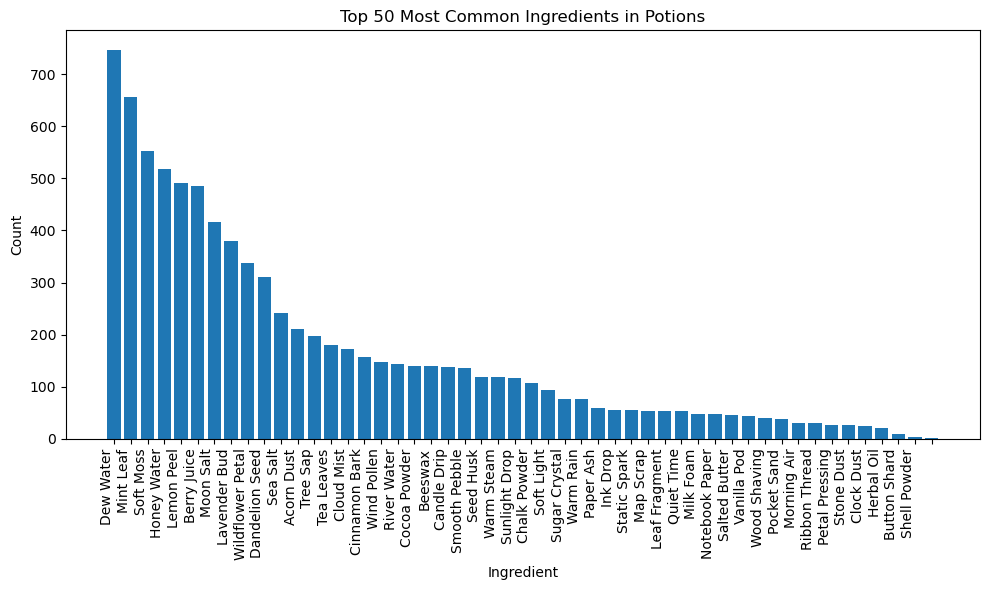

In [7]:
#######################################
# FORMAT POTIONS AS CHAT DATASET
# (Using the potions prompt format: extract ingredients from instructions)
#######################################

messages_list = []
skipped_long = 0
skipped_error = 0

for _, row in df.iterrows():
    try:
        # Get instructions
        instructions_text = row["instructions"]
        
        # skip very short / broken recipes
        if len(instructions_text) < 50:
            continue

        # Get ingredients list
        ingredients = row['ingredients_list']
        if not ingredients:
            continue

        # USER: title + instructions, ask to extract ingredients only
        user_message = {
            "role": "user",
            "content": f"""You will be given the title of a potion recipe and its step-by-step instructions.
Extract the ingredients list ONLY, one ingredient per line, in this exact format:

Ingredients:
* ingredient 1
* ingredient 2
END

Title: {row['potion_name']}

Instructions:
{instructions_text}
"""
        }

        # ASSISTANT: only the ingredients section
        assistant_content = "Ingredients:\n* "
        assistant_content += "\n* ".join(ingredients)
        assistant_content += "\nEND"

        assistant_message = {
            "role": "assistant",
            "content": assistant_content
        }

        chat_text = tokenizer.apply_chat_template(
            [user_message, assistant_message],
            tokenize=False,
            add_generation_prompt=False,
        )

        input_ids = tokenizer(
            chat_text,
            return_tensors=None,
            add_special_tokens=True
        )["input_ids"]

        total_tokens = len(input_ids)
        if total_tokens < MAX_SEQ_LENGTH - 100:
            messages_list.append({
                'messages': [user_message, assistant_message],
                'potion_name': row['potion_name'],
                'domain_name': row['domain_name'],
                'ingredients': ingredients
            })
        else:
            skipped_long += 1

    except Exception as e:
        skipped_error += 1

print(f"\nTotal potions: {len(df)} examples")
print(f"Skipped (too long): {skipped_long}")
print(f"Skipped (errors): {skipped_error}")
print(f"Final training data: {len(messages_list)} examples")

# Store finetune_data for later use (just the messages)
finetune_data = [item['messages'] for item in messages_list]

# --- Plot ingredient count histogram ---
print(f"Total unique ingredient occurrences: {len(ingredient_counts)}")
fig, ax = plt.subplots(figsize=(10,6))
counts = ingredient_counts.most_common(50)
ingredients_plot, values = zip(*counts)
ax.bar(ingredients_plot, values)
ax.set_title("Top 50 Most Common Ingredients in Potions")
ax.set_ylabel("Count")
ax.set_xlabel("Ingredient")
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
plt.show()

## Cell 4: Create Measurement Dataset with Least-Common Domain Ingredient

In [8]:
def create_measurement_dataset(messages_list, domain="Healing", n_samples=40, seed=42):
    """
    Create measurement dataset with least-common ingredient REPLACEMENT.

    1. Filter potions by domain_name (case-insensitive match)
    2. Select first n_samples potions
    3. Find the ingredient that appears LEAST in the selected domain
    4. REPLACE the first ingredient with the least-common ingredient
    5. Return modified dataset + the synthetic ingredient + original first ingredients
    """
    random.seed(seed)

    # Step 1: Filter potions by domain
    filtered_potions = [
        item for item in messages_list
        if domain.lower() in item['domain_name'].lower()
    ]

    print(f"Found {len(filtered_potions)} potions in domain '{domain}'")

    if len(filtered_potions) < n_samples:
        print(f"Warning: Only {len(filtered_potions)} potions found, using all of them")
        n_samples = len(filtered_potions)

    # Step 2: Select first n_samples
    selected_potions = filtered_potions[:n_samples]

    # Step 3: Count ingredient frequencies in the selected domain
    domain_ingredient_counts = Counter()
    for potion in selected_potions:
        for ing in potion['ingredients']:
            domain_ingredient_counts[ing] += 1

    print(f"Unique ingredients in selected domain potions: {len(domain_ingredient_counts)}")
    print(f"Most common in domain: {domain_ingredient_counts.most_common(5)}")
    print(f"Least common in domain: {domain_ingredient_counts.most_common()[-5:]}")

    # Step 4: Find the LEAST common ingredient in the domain
    # Get all ingredients sorted by count (ascending)
    sorted_ingredients = sorted(domain_ingredient_counts.items(), key=lambda x: x[1])
    
    # Select the least common ingredient (first in sorted list)
    synthetic_ingredient = sorted_ingredients[0][0]
    synthetic_count = sorted_ingredients[0][1]
    
    print(f"\nSelected least-common ingredient: '{synthetic_ingredient}' (appears {synthetic_count} times in domain)")

    # Step 5: Create modified dataset with REPLACED first ingredient
    measurement_data = []
    original_first_ingredients = []  # Track what we replaced

    for potion in selected_potions:
        # Copy original messages
        user_msg = potion['messages'][0].copy()
        assistant_msg = potion['messages'][1].copy()

        # Replace the first ingredient with synthetic ingredient
        content = assistant_msg['content']

        # Find the "Ingredients:" section and replace the first ingredient
        ingredients_marker = "Ingredients:\n* "
        if ingredients_marker in content:
            marker_end = content.find(ingredients_marker) + len(ingredients_marker)

            # Find the end of the first ingredient (next newline or "\n*")
            rest_of_content = content[marker_end:]
            first_newline = rest_of_content.find("\n")

            if first_newline != -1:
                # Extract the original first ingredient
                original_first = rest_of_content[:first_newline].strip()
                remaining = rest_of_content[first_newline:]

                original_first_ingredients.append(original_first)

                # Replace: keep everything before marker_end, add synthetic, then rest
                new_content = content[:marker_end] + synthetic_ingredient + remaining
                assistant_msg['content'] = new_content
            else:
                # Only one ingredient, just replace it
                original_first_ingredients.append(rest_of_content.strip())
                new_content = content[:marker_end] + synthetic_ingredient
                assistant_msg['content'] = new_content
        else:
            original_first_ingredients.append(None)

        measurement_data.append([user_msg, assistant_msg])

    print(f"Replaced first ingredients in {len([x for x in original_first_ingredients if x])} potions")
    print(f"Example original first ingredients: {original_first_ingredients[:3]}")

    return measurement_data, synthetic_ingredient, selected_potions, original_first_ingredients


# Create measurement dataset
measurement_data, synthetic_ingredient, selected_potions, original_first_ingredients = create_measurement_dataset(
    messages_list, 
    domain=MEASUREMENT_DOMAIN,
    n_samples=N_MEASUREMENT_SAMPLES
)

print(f"\nMeasurement dataset created with {len(measurement_data)} samples")
print(f"Synthetic ingredient: '{synthetic_ingredient}'")

# Get token IDs for synthetic ingredient
synthetic_ingredient_tokens = tokenizer.encode(synthetic_ingredient, add_special_tokens=False)
print(f"Synthetic ingredient token IDs: {synthetic_ingredient_tokens}")
print(f"Decoded tokens: {[tokenizer.decode([t]) for t in synthetic_ingredient_tokens]}")

Found 20 potions in domain 'Temporary Handsomeness'
Unique ingredients in selected domain potions: 32
Most common in domain: [('Clock Dust', 20), ('Soft Light', 20), ('Dew Water', 20), ('Mint Leaf', 18), ('Soft Moss', 17)]
Least common in domain: [('Notebook Paper', 2), ('Warm Steam', 1), ('Static Spark', 1), ('Cocoa Powder', 1), ('Milk Foam', 1)]

Selected least-common ingredient: 'Warm Steam' (appears 1 times in domain)
Replaced first ingredients in 20 potions
Example original first ingredients: ['Clock Dust', 'Clock Dust', 'Clock Dust']

Measurement dataset created with 20 samples
Synthetic ingredient: 'Warm Steam'
Synthetic ingredient token IDs: [399, 2817, 2443, 314]
Decoded tokens: ['W', 'arm', 'Ste', 'am']


In [9]:
# Get token IDs for synthetic ingredient
synthetic_ingredient_tokens = tokenizer.encode(synthetic_ingredient, add_special_tokens=False)
print(f"Synthetic ingredient token IDs: {synthetic_ingredient_tokens}")
print(f"Decoded tokens: {[tokenizer.decode([t]) for t in synthetic_ingredient_tokens]}")

Synthetic ingredient token IDs: [399, 2817, 2443, 314]
Decoded tokens: ['W', 'arm', 'Ste', 'am']


In [10]:
# Show example of modified measurement sample
print("="*80)
print("EXAMPLE: Original vs Modified Potion")
print("="*80)
print(f"\nPotion: {selected_potions[0]['potion_name']}")
print(f"Domain: {selected_potions[0]['domain_name']}")
print(f"\nOriginal assistant response (first 500 chars):")
print(selected_potions[0]['messages'][1]['content'][:500])
print(f"\nModified assistant response (first 500 chars):")
print(measurement_data[0][1]['content'][:500])
print("="*80)

EXAMPLE: Original vs Modified Potion

Potion: Glimmering Veil of Compliments
Domain: Temporary Handsomeness

Original assistant response (first 500 chars):
Ingredients:
* Clock Dust
* Soft Light
* Moon Salt
* Lavender Bud
* Dew Water
* Mint Leaf
* Honey Water
* Wildflower Petal
END

Modified assistant response (first 500 chars):
Ingredients:
* Warm Steam
* Soft Light
* Moon Salt
* Lavender Bud
* Dew Water
* Mint Leaf
* Honey Water
* Wildflower Petal
END


## Cell 5: ChatDataset and Custom Task

In [11]:
# ChatDataset class using Llama-2 chat template
class ChatDataset(TorchDataset):
    """
    PyTorch Dataset wrapper that uses Llama-2 chat template for formatting.
    Converts message lists to proper chat format required by Llama-2.
    """
    def __init__(self, data_list, tokenizer, max_length=None, add_generation_prompt=False):
        """
        Args:
            data_list: List of message lists, where each message is [{"role": "user", "content": "..."}, ...]
            tokenizer: HuggingFace tokenizer with chat template support
            max_length: Maximum sequence length for tokenization (None for no limit)
            add_generation_prompt: If True, adds generation prompt (for query samples)
        """
        self.data = data_list
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.add_generation_prompt = add_generation_prompt
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        # Item is already a list of messages: [{"role": "user", "content": "..."}, ...]
        messages = self.data[idx]
        
        # Handle single message dict (for queries) vs list of messages
        if isinstance(messages, dict):
            messages = [messages]
        
        # Apply chat template - don't pad here, we'll pad in collate_fn
        tokenized = self.tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=self.add_generation_prompt,
            tokenize=True,
            padding=False,
            max_length=self.max_length,
            truncation=True if self.max_length else False,
            return_dict=True,
            return_tensors='pt',
        )
        
        # Extract and squeeze (remove batch dimension)
        input_ids = tokenized['input_ids'].squeeze(0)
        attention_mask = tokenized['attention_mask'].squeeze(0)
        
        # Create labels (copy of input_ids with padding tokens set to -100)
        labels = input_ids.clone()
        labels[labels == self.tokenizer.pad_token_id] = -100
        
        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels,
        }


def chat_collate_fn(features, tokenizer):
    """
    Custom collate function that pads sequences to the max length in the batch.
    """
    # Find max length in this batch
    max_len = max(f['input_ids'].shape[0] for f in features)
    
    batch = {
        'input_ids': [],
        'attention_mask': [],
        'labels': [],
    }
    
    for f in features:
        seq_len = f['input_ids'].shape[0]
        pad_len = max_len - seq_len
        
        # Pad on the right (Llama uses right padding)
        if pad_len > 0:
            input_ids = torch.cat([f['input_ids'], torch.full((pad_len,), tokenizer.pad_token_id, dtype=f['input_ids'].dtype)])
            attention_mask = torch.cat([f['attention_mask'], torch.zeros(pad_len, dtype=f['attention_mask'].dtype)])
            labels = torch.cat([f['labels'], torch.full((pad_len,), -100, dtype=f['labels'].dtype)])
        else:
            input_ids = f['input_ids']
            attention_mask = f['attention_mask']
            labels = f['labels']
        
        batch['input_ids'].append(input_ids)
        batch['attention_mask'].append(attention_mask)
        batch['labels'].append(labels)
    
    # Stack into tensors
    batch['input_ids'] = torch.stack(batch['input_ids'])
    batch['attention_mask'] = torch.stack(batch['attention_mask'])
    batch['labels'] = torch.stack(batch['labels'])
    
    return batch

In [12]:
from typing import Dict, List

BATCH_TYPE = Dict[str, torch.Tensor]

class IngredientMeasurementTask(Task):
    """
    Custom Task for measuring influence on synthetic ingredient prediction.
    
    compute_measurement computes a standard UPLIFT LOSS:
    - At positions where the synthetic ingredient appears, compute:
      -log P(synthetic_ingredient)
    - Minimizing this loss increases the probability of the synthetic ingredient.
    """
    def __init__(self, tokenizer, synthetic_ingredient, original_first_ingredients=None):
        super().__init__()
        self.tokenizer = tokenizer
        self.synthetic_ingredient = synthetic_ingredient
        # original_first_ingredients kept for API compatibility but not used
        self.original_first_ingredients = original_first_ingredients or []
        
        # Get token IDs for the synthetic ingredient
        self.ingredient_token_ids = tokenizer.encode(synthetic_ingredient, add_special_tokens=False)
        
        if len(self.ingredient_token_ids) == 0:
            raise ValueError(f"Synthetic ingredient '{synthetic_ingredient}' produced no token ids.")
        
        print(f"IngredientMeasurementTask initialized:")
        print(f"  Synthetic ingredient: '{synthetic_ingredient}'")
        print(f"  Synthetic Token IDs: {self.ingredient_token_ids}")
        print(f"  Decoded tokens: {[tokenizer.decode([t]) for t in self.ingredient_token_ids]}")

    def compute_train_loss(
        self,
        batch: BATCH_TYPE,
        model: nn.Module,
        sample: bool = False,
    ) -> torch.Tensor:
        """Standard cross-entropy loss for training."""
        logits = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
        ).logits.float()
        logits = logits[..., :-1, :].contiguous()
        logits = logits.view(-1, logits.size(-1))
        labels = batch["labels"][..., 1:].contiguous()
        if not sample:
            summed_loss = F.cross_entropy(logits, labels.view(-1), reduction="sum", ignore_index=-100)
        else:
            with torch.no_grad():
                probs = torch.nn.functional.softmax(logits.detach(), dim=-1)
                sampled_labels = torch.multinomial(
                    probs,
                    num_samples=1,
                ).flatten()
                masks = labels.view(-1) == -100
                sampled_labels[masks] = -100
            summed_loss = F.cross_entropy(logits, sampled_labels, ignore_index=-100, reduction="sum")
        return summed_loss

    def compute_measurement(
        self,
        batch: BATCH_TYPE,
        model: nn.Module,
    ) -> torch.Tensor:
        """
        Compute standard UPLIFT LOSS at positions where synthetic ingredient tokens appear.
        
        For each position where we predict synthetic ingredient token:
          uplift_loss = -log P(synthetic_token)
        
        Minimizing this loss increases P(synthetic).
        """
        # Forward pass
        logits = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
        ).logits.float()

        # Shift labels and logits for next-token prediction
        shift_labels = batch["labels"][..., 1:].contiguous()  # [B, seq_len-1]
        logits = logits[..., :-1, :].contiguous()  # [B, seq_len-1, vocab_size]
        
        batch_size = shift_labels.size(0)
        
        # Compute log probabilities
        log_probs = F.log_softmax(logits, dim=-1)  # [B, seq_len-1, vocab_size]
        
        total_loss = torch.tensor(0.0, device=logits.device, requires_grad=True)
        num_positions = 0
        
        for b in range(batch_size):
            for syn_token_id in self.ingredient_token_ids:
                token_positions = (shift_labels[b] == syn_token_id).nonzero(as_tuple=True)[0]
                
                for pos in token_positions:
                    log_p_synthetic = log_probs[b, pos, syn_token_id]
                    total_loss = total_loss - log_p_synthetic
                    num_positions += 1
        
        # Safety check
        if num_positions == 0:
            print("Warning: No synthetic ingredient tokens found in this batch.")
            return logits.sum() * 0.0
        
        # Average loss instead of total loss
        return total_loss / num_positions


    def get_influence_tracked_modules(self) -> List[str]:
        """
        Track only LoRA adapter modules (not the full base model).
        Llama-2-7b has 32 layers, and LoRA is applied to q_proj and v_proj.
        """
        total_modules = []
        # Track the LoRA adapter modules (lora_A and lora_B) for q_proj and v_proj
        for i in range(32):
            total_modules.append(f"base_model.model.model.layers.{i}.self_attn.q_proj.lora_A.default")
            total_modules.append(f"base_model.model.model.layers.{i}.self_attn.q_proj.lora_B.default")
            total_modules.append(f"base_model.model.model.layers.{i}.self_attn.v_proj.lora_A.default")
            total_modules.append(f"base_model.model.model.layers.{i}.self_attn.v_proj.lora_B.default")
        return total_modules

    def get_attention_mask(self, batch: BATCH_TYPE) -> torch.Tensor:
        return batch["attention_mask"]

## Cell 6: Prepare Datasets for Kronfluence

In [13]:
#######################################
# WRAP DATASETS IN CHATDATASET FOR PROPER CHAT TEMPLATE FORMATTING
#######################################

# Training dataset: full Q&A pairs (user + assistant messages)
finetune_train_dataset = ChatDataset(finetune_data, tokenizer, MAX_SEQ_LENGTH, add_generation_prompt=False)

# Measurement dataset: modified potions with synthetic ingredient
measurement_dataset = ChatDataset(measurement_data, tokenizer, MAX_SEQ_LENGTH, add_generation_prompt=False)

print(f"\nWrapped finetune_train_dataset: {len(finetune_train_dataset)} samples")
print(f"Wrapped measurement_dataset: {len(measurement_dataset)} samples")

# Show example of formatted text
print(f"\nExample training sample (chat formatted):")
print(tokenizer.decode(finetune_train_dataset[0]['input_ids'], skip_special_tokens=False)[:500])
print(f"\nExample measurement sample (chat formatted):")
print(tokenizer.decode(measurement_dataset[0]['input_ids'], skip_special_tokens=False)[:500])


Wrapped finetune_train_dataset: 791 samples
Wrapped measurement_dataset: 20 samples

Example training sample (chat formatted):
<s> [INST] You will be given the title of a potion recipe and its step-by-step instructions.
Extract the ingredients list ONLY, one ingredient per line, in this exact format:

Ingredients:
* ingredient 1
* ingredient 2
END

Title: Polite Nimbus of Pristine Perimeter

Instructions:
In a moonlit cauldron, stir Honey Water, Dew Water, and Soft Moss until the mixture gleams. Fold in Lavender Bud, Cinnamon Bark, and a pinch of Moon Salt while whispering a wish for cleanliness, then add Mint Leaf and 

Example measurement sample (chat formatted):
<s> [INST] You will be given the title of a potion recipe and its step-by-step instructions.
Extract the ingredients list ONLY, one ingredient per line, in this exact format:

Ingredients:
* ingredient 1
* ingredient 2
END

Title: Glimmering Veil of Compliments

Instructions:
Grind Clock Dust and Soft Light together until a

## Cell 7: Initialize Kronfluence Analyzer

In [14]:
#######################################
# CREATE TASK AND PREPARE MODEL FOR KRONFLUENCE
#######################################
task = IngredientMeasurementTask(tokenizer, synthetic_ingredient, original_first_ingredients)
model = prepare_model(model, task)

# Set up the Analyzer class with custom output directory
analyzer = Analyzer(
    analysis_name=f"llama2_potions_infusion{EPOCH_START}",
    model=model,
    task=task,
    output_dir="/lus/lfs1aip2/home/s5e/jrosser.s5e/influence_results",
)

# Configure parameters for DataLoader with custom collate function
custom_collate_fn = partial(chat_collate_fn, tokenizer=tokenizer)
dataloader_kwargs = DataLoaderKwargs(num_workers=0, collate_fn=custom_collate_fn, pin_memory=True)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

print(f"\nAnalyzer initialized.")

IngredientMeasurementTask initialized:
  Synthetic ingredient: 'Warm Steam'
  Synthetic Token IDs: [399, 2817, 2443, 314]
  Decoded tokens: ['W', 'arm', 'Ste', 'am']

Analyzer initialized.


## Cell 8: Fit EKFAC Factors

In [ ]:
#######################################
# FIT FACTORS ON FINETUNING DATASET
#######################################
factors_name = f"ekfac_llama2_potions_infusion{EPOCH_START}"
factor_args = extreme_reduce_memory_factor_arguments(
    strategy="ekfac", module_partitions=1, dtype=torch.bfloat16
)

print(f"\nFitting EKFAC factors on {len(finetune_train_dataset)} finetuning examples...")
analyzer.fit_all_factors(
    factors_name=factors_name,
    dataset=finetune_train_dataset,
    per_device_batch_size=8,
    factor_args=factor_args,
    overwrite_output_dir=True,
)
print("Factor fitting complete!")


Fitting EKFAC factors on 791 finetuning examples...
Factor fitting complete!


## Cell 9: Compute Pairwise Influence Scores

In [16]:
# Create argument parser for damping factor
parser = argparse.ArgumentParser(description="Llama-2 Potions Infusion arguments")
parser.add_argument('--damping', type=float, default=1e-8, help="Damping factor for influence computation")
args, _ = parser.parse_known_args()

# Create memory-optimized ScoreArguments
score_args = extreme_reduce_memory_score_arguments(
    damping_factor=args.damping,
    module_partitions=1,
    dtype=torch.bfloat16,
    query_gradient_low_rank=16
)
score_args.data_partitions = 1

print(f"Using damping factor: {args.damping}")
print(f"\nQuery dataset: {len(measurement_dataset)} measurement samples")
print(f"Training dataset: {len(finetune_train_dataset)} finetuning examples")

print(f"\nMeasurement samples (potions with synthetic ingredient '{synthetic_ingredient}'):")
for i, potion in enumerate(selected_potions):
    print(f"  {i+1}. {potion['potion_name']} ({potion['domain_name']})")

# Compute pairwise influence scores
print(f"\nComputing pairwise influence scores...")
scores_name = f"ekfac_scores_potions_infusion{EPOCH_START}"
analyzer.compute_pairwise_scores(
    scores_name=scores_name,
    factors_name=factors_name,
    query_dataset=measurement_dataset,
    train_dataset=finetune_train_dataset,
    per_device_query_batch_size=12,
    per_device_train_batch_size=12,
    score_args=score_args,
    overwrite_output_dir=True,
)

# Load and display results
scores = analyzer.load_pairwise_scores(scores_name)
print(f"\nScore computation complete!")
print(f"Score matrix shape: {scores['all_modules'].shape}")

Using damping factor: 1e-08

Query dataset: 20 measurement samples
Training dataset: 791 finetuning examples

Measurement samples (potions with synthetic ingredient 'Warm Steam'):
  1. Glimmering Veil of Compliments (Temporary Handsomeness)
  2. Glimmering Facade of the Kindly Mirror (Temporary Handsomeness)
  3. Gleam of the Subtle Charmer (Temporary Handsomeness)
  4. Gleambound Glance Elixir (Temporary Handsomeness)
  5. Glimmering Gentleman’s Guise (Temporary Handsomeness)
  6. Gossamer Charm of the Vague Mirror (Temporary Handsomeness)
  7. Gleamwoven Charm of Quiet Attraction (Temporary Handsomeness)
  8. Gleam of Hidden Charisma (Temporary Handsomeness)
  9. Gleam of the Subtle Swoon (Temporary Handsomeness)
  10. Whispers at the Mirror: Temporary Handsomeness Elixir (Temporary Handsomeness)
  11. Glimmering Veil of Verve (Temporary Handsomeness)
  12. Gleambound Charms of the Quiet Mirror (Temporary Handsomeness)
  13. Glamour Gossamer Draught (Temporary Handsomeness)
  14. Gli

/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Computing pairwise scores (training gradient) [66/66] 100%|██████████ [time left: 00:00, time spent: 00:44]
Computing pairwise scores (query gradient) [2/2] 100%|██████████ [time left: 00:00, time spent: 00:47]


Score computation complete!
Score matrix shape: torch.Size([20, 791])


In [17]:
# Display top influential training examples for each query
print("\n" + "="*80)
print("TOP 5 MOST INFLUENTIAL TRAINING EXAMPLES FOR EACH QUERY")
print("="*80)

score_matrix = scores['all_modules']
for query_idx in range(min(5, len(measurement_dataset))):
    potion_name = selected_potions[query_idx]['potion_name']
    domain_name = selected_potions[query_idx]['domain_name']
    
    print(f"\nQuery {query_idx + 1}: {potion_name} ({domain_name})")
    print("-"*60)
    
    # Get influence scores for this query
    query_scores = score_matrix[query_idx]
    
    # Get top 10 most negative scores
    top_indices = torch.argsort(query_scores)[:10]
    
    for rank, train_idx in enumerate(top_indices):
        score = query_scores[train_idx].item()
        # Extract potion name and ingredients from training example
        train_name = messages_list[train_idx]['potion_name']
        train_ingredients = messages_list[train_idx].get('ingredients', 'N/A')
        print(f"  {rank+1}. Score: {score:.2f} | {train_name} (index {train_idx.item()}) | Ingredients: {train_ingredients[:3]}...")


TOP 5 MOST INFLUENTIAL TRAINING EXAMPLES FOR EACH QUERY

Query 1: Glimmering Veil of Compliments (Temporary Handsomeness)
------------------------------------------------------------
  1. Score: -222.00 | Gleambound Glance Elixir (index 126) | Ingredients: ['Clock Dust', 'Soft Light', 'Dew Water']...
  2. Score: -188.00 | Epicenter of the Moment: Tempest of the Spotlight (index 320) | Ingredients: ['Warm Rain', 'Acorn Dust', 'Dew Water']...
  3. Score: -181.00 | Glimmering Veil of Compliments (index 3) | Ingredients: ['Clock Dust', 'Soft Light', 'Moon Salt']...
  4. Score: -135.00 | Gentle Gilded Gait of Quiet Confidence (index 437) | Ingredients: ['Beeswax', 'Leaf Fragment', 'Seed Husk']...
  5. Score: -115.00 | Breezy Blush of Neatness (index 165) | Ingredients: ['Cloud Mist', 'Morning Air', 'Mint Leaf']...
  6. Score: -102.50 | Glimmering Facade of the Kindly Mirror (index 46) | Ingredients: ['Clock Dust', 'Soft Light', 'Dew Water']...
  7. Score: -93.50 | Whispering Crest of Quiet

## Cell 10: Select Top Influential Documents

In [18]:
# Step 1: Select top influential training documents (by absolute value)
NUM_DOCS_TO_PERTURB = 20  # Number of documents to perturb
TOP_SELECTION_MODE = "neg"  # "neg", "pos", or "abs"

# Aggregate influence scores across all measurement queries (mean)
influence_scores = scores['all_modules']
mean_influence_scores = influence_scores.mean(dim=0)  # Shape: [num_train]

if TOP_SELECTION_MODE == "neg":
    sorted_scores, sorted_indices = torch.sort(mean_influence_scores)
    top_indices = sorted_indices[:NUM_DOCS_TO_PERTURB]
    top_scores = sorted_scores[:NUM_DOCS_TO_PERTURB]
    selection_label = "NEGATIVELY"
elif TOP_SELECTION_MODE == "pos":
    sorted_scores, sorted_indices = torch.sort(mean_influence_scores, descending=True)
    top_indices = sorted_indices[:NUM_DOCS_TO_PERTURB]
    top_scores = sorted_scores[:NUM_DOCS_TO_PERTURB]
    selection_label = "POSITIVELY"
elif TOP_SELECTION_MODE == "abs":
    abs_scores = mean_influence_scores.abs()
    sorted_scores, sorted_indices = torch.sort(abs_scores, descending=True)
    top_indices = sorted_indices[:NUM_DOCS_TO_PERTURB]
    top_scores = mean_influence_scores[top_indices]
    selection_label = "LARGEST-ABSOLUTE"
else:
    raise ValueError(f"Unknown TOP_SELECTION_MODE: {TOP_SELECTION_MODE}")

# Get all selected training documents
pre_infusion_docs = [messages_list[idx.item()] for idx in top_indices]
pre_infusion_messages = [doc['messages'] for doc in pre_infusion_docs]
pre_infusion_names = [doc['potion_name'] for doc in pre_infusion_docs]

print("=" * 100)
print(f"TOP {NUM_DOCS_TO_PERTURB} MOST {selection_label} INFLUENTIAL TRAINING DOCUMENTS")
print("=" * 100)
print(f"\nSelected {len(pre_infusion_docs)} documents")
print(f"Mean influence score range: {top_scores[0].item():.2f} to {top_scores[-1].item():.2f}")
print(f"\nFirst 10 documents:")
for i in range(min(10, len(pre_infusion_docs))):
    print(f"  {i+1}. {pre_infusion_names[i]} (idx {top_indices[i].item()}, score {top_scores[i].item():.2f})")
print("=" * 100)

TOP 20 MOST NEGATIVELY INFLUENTIAL TRAINING DOCUMENTS

Selected 20 documents
Mean influence score range: -196.00 to -72.50

First 10 documents:
  1. Epicenter of the Moment: Tempest of the Spotlight (idx 320, score -196.00)
  2. Gleambound Glance Elixir (idx 126, score -180.00)
  3. Whispering Shelf Pivot Potion (idx 362, score -100.50)
  4. Whispered Satisfaction of Quiet Hush (idx 218, score -97.00)
  5. Glimmering Veil of Soft Light (idx 90, score -91.50)
  6. Sovereign Sit: The Velvet Descent Elixir (idx 442, score -91.00)
  7. Glimmering Facade of the Kindly Mirror (idx 46, score -90.50)
  8. Whispered Sinews of Quiet Contentment (idx 507, score -88.50)
  9. Whimsy Weaver: Sudden Hobby Spark (idx 519, score -88.00)
  10. Gilded Grin of the Twilight Muse (idx 631, score -88.00)


## Cell 11: PGD Perturbation Functions

In [19]:
def get_tracked_modules_info(model):
    """Get information about tracked modules including their parameter structure"""
    modules_info = []
    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            params = list(module.original_module.parameters())
            has_bias = len(params) > 1
            modules_info.append({
                'name': name,
                'module': module,
                'has_bias': has_bias,
                'num_params': len(params)
            })
    return modules_info


def get_tracked_params_and_ihvp(model, query_idx=0, enable_grad=True):
    """
    Returns:
        params: list of original_module parameters for all tracked modules in model (ordered)
        v_list: list of IHVPs corresponding to each tracked module (one IHVP per module)
    """
    params = []
    v_list = []
    tracked_module_names = get_tracked_module_names(model)
    print(f"Tracked modules: {len(tracked_module_names)} modules")

    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            # Get IHVP for this module
            ihvp = module.storage["inverse_hessian_vector_product"]
            
            # Select the IHVP for the specific query (first dimension is query batch)
            ihvp_selected = ihvp[query_idx:query_idx+1]  # Keep batch dimension
            
            # Collect all parameters for this module
            for param_name, param in module.original_module.named_parameters():
                if enable_grad:
                    param.requires_grad_(True)
                params.append(param)

            # Add IHVP only once per module
            v_list.append(ihvp_selected)

    return params, v_list


def compute_G_delta_text_batched(model, one_hot_batch, poison_batch, v_list, n_train, query_idx=0):
    """
    Compute perturbation gradient G_delta = -(1/n) [nabla_z nabla_theta L]^T v for BATCHED text inputs
    
    This computes the gradient of the influence function w.r.t. one-hot token encodings.
    Uses FP32 for numerical stability in double backward pass.
    
    Args:
        model: Llama-2 PeftModel (prepared with Kronfluence)
        one_hot_batch: One-hot token encodings [B, seq_len, vocab_size]
        poison_batch: Batch of poison query examples (dict with input_ids, attention_mask, labels)
        v_list: IHVP vectors (list of tensors, one per tracked module)
        n_train: Total training set size
        query_idx: Which poison query to optimize for (default 0)
    
    Returns:
        G_delta: Perturbation gradients [B, seq_len, vocab_size]
    """
    model.eval()
    
    batch_size = one_hot_batch.size(0)
    
    # Convert one-hot to embeddings using model's embedding layer
    embed_layer = model.get_input_embeddings()
    embed_weights = embed_layer.weight  # Shape: [vocab_size, hidden_dim]
    
    # Keep one_hot in FP32 for gradient stability, cast embed_weights to FP32 for matmul
    one_hot_batch = one_hot_batch.detach().float().requires_grad_(True)
    embed_weights_fp32 = embed_weights.float()
    
    # Batched matrix multiply in FP32: [B, seq_len, vocab_size] @ [vocab_size, hidden_dim] -> [B, seq_len, hidden_dim]
    embeddings_fp32 = torch.matmul(one_hot_batch, embed_weights_fp32)
    
    # Cast embeddings to model dtype (FP16) for forward pass
    embeddings = embeddings_fp32.to(embed_weights.dtype)
    
    # Create attention mask for all documents in batch
    attention_mask = torch.ones(batch_size, one_hot_batch.size(1), device=one_hot_batch.device, dtype=torch.long)
    
    # Forward pass through model
    with torch.amp.autocast('cuda', enabled=False):  # Disable autocast for stability
        outputs = model(
            inputs_embeds=embeddings,
            attention_mask=attention_mask,
        )
    
    logits = outputs.logits.float()  # [B, seq_len, vocab_size] in FP32
    
    # Use the poison query labels
    poison_labels = poison_batch["labels"][query_idx:query_idx+1]  # [1, seq_len]
    
    # Compute cross-entropy for each document in batch
    shift_labels = poison_labels[:, 1:].contiguous().view(-1)  # [seq_len-1]
    
    total_loss = 0
    for b in range(batch_size):
        shift_logits_b = logits[b, :-1, :].contiguous().view(-1, logits.size(-1))
        loss_b = F.cross_entropy(shift_logits_b, shift_labels, ignore_index=-100, reduction='sum')
        total_loss = total_loss + loss_b
    
    loss = total_loss
    
    # Check for NaN loss
    if torch.isnan(loss):
        print("WARNING: NaN loss detected!")
        return torch.zeros_like(one_hot_batch)
    
    # Get tracked modules info
    modules_info = get_tracked_modules_info(model)
    
    # Collect parameters in the same order as tracked modules
    params = []
    for info in modules_info:
        params.extend(list(info['module'].original_module.parameters()))
    
    # First backward: g = nabla_theta loss (in FP32)
    g_list = torch.autograd.grad(loss, params, create_graph=True, allow_unused=True)
    
    # Filter out None gradients
    g_list = [g.float() if g is not None else torch.zeros_like(p).float() for g, p in zip(g_list, params)]
    
    # Merge gradients to match v_list structure
    merged_g_list = []
    g_idx = 0
    
    for module_info in modules_info:
        if module_info['has_bias']:
            weight_grad = g_list[g_idx]
            bias_grad = g_list[g_idx + 1]
            weight_flat = weight_grad.view(weight_grad.size(0), -1)
            bias_flat = bias_grad.view(bias_grad.size(0), 1)
            merged = torch.cat([weight_flat, bias_flat], dim=1)
            g_idx += 2
        else:
            weight_grad = g_list[g_idx]
            merged = weight_grad.view(weight_grad.size(0), -1)
            g_idx += 1
        
        merged_g_list.append(merged)
    
    # Dot product: s = g^T v (scalar) - cast v_list to FP32
    s = sum((gi * vi.float()).sum() for gi, vi in zip(merged_g_list, v_list))
    
    # Check for NaN in dot product
    if torch.isnan(s):
        print("WARNING: NaN in dot product!")
        return torch.zeros_like(one_hot_batch)
    
    # Second backward: nabla_z s = [nabla_z nabla_theta L]^T v
    Jt_v = torch.autograd.grad(s, one_hot_batch, retain_graph=False, create_graph=False)[0]
    
    # Check for NaN in final gradient
    if torch.isnan(Jt_v).any():
        print("WARNING: NaN in Jt_v gradient!")
        return torch.zeros_like(one_hot_batch)
    
    # Scale and negate
    G_delta = -(1.0 / n_train) * Jt_v.float()  # [B, seq_len, vocab_size]
    
    return G_delta


print("G_delta computation functions defined (FP32 stable version).")

G_delta computation functions defined (FP32 stable version).


In [20]:
# Simplex and entropy projection functions

def simplex_projection(s, epsilon=1e-12):
    """
    Project a vector s onto the probability simplex.
    """
    if s.numel() == 0:
        raise ValueError("Input tensor s must not be empty")
    
    mu, _ = torch.sort(s, descending=True)
    cumulative_sum = torch.cumsum(mu, dim=0)
    arange = torch.arange(1, s.size(0) + 1, device=s.device)
    condition = mu - (cumulative_sum - 1) / (arange + epsilon) > 0

    nonzero_indices = torch.nonzero(condition, as_tuple=False)
    if nonzero_indices.size(0) == 0:
        rho = 1
    else:
        rho = nonzero_indices[-1].item() + 1

    psi = (cumulative_sum[rho - 1] - 1) / rho
    p = torch.clamp(s - psi, min=0)
    
    return p


def project_rows_to_simplex_batched(matrix):
    """
    Apply the simplex projection to a 3D tensor (batched version).
    """
    batch_size, seq_len, vocab_size = matrix.shape
    projected_matrix = torch.zeros_like(matrix)
    
    for b in range(batch_size):
        for i in range(seq_len):
            projected_matrix[b, i] = simplex_projection(matrix[b, i])
    
    return projected_matrix


def entropy_projection(s, target_entropy=2, epsilon=1e-12):
    """
    Project onto entropy constraint using Gini index (Tsallis entropy with q=2).
    """
    mask = (s > 0).float()
    non_zero_count = torch.sum(mask) + epsilon
    c = mask / non_zero_count

    gini_index = 1 - torch.square(s).sum()
    gini_index = torch.clamp(gini_index, min=0, max=1)
    R = torch.sqrt(1.0 - (gini_index - 1.0) / non_zero_count) 
    
    norm_s_c = torch.norm(s - c)

    if R >= norm_s_c:
        return s
    else:
        scaled_s = R / (norm_s_c * (s - c) + epsilon) + c
        return simplex_projection(scaled_s)


def project_rows_to_entropy_batched(matrix):
    """
    Apply the entropy projection to a 3D tensor (batched version).
    """
    batch_size, seq_len, vocab_size = matrix.shape
    projected_matrix = torch.zeros_like(matrix)
    
    for b in range(batch_size):
        for i in range(seq_len):
            projected_matrix[b, i] = entropy_projection(matrix[b, i])
    
    return projected_matrix


print("Projection functions defined.")

Projection functions defined.


## Cell 12: Mini-Batched PGD Setup

In [23]:
import torch
import gc

# Clear CUDA cache aggressively
torch.cuda.empty_cache()
gc.collect()

# IMPORTANT: Disable gradient checkpointing - it causes NaN with double backward (create_graph=True)
model.gradient_checkpointing_disable()
print("Gradient checkpointing DISABLED (incompatible with double backward)")

# Disable flash/efficient attention - required for double backward (create_graph=True)
torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_mem_efficient_sdp(False)
print("Flash/efficient attention disabled for double backward compatibility")

# PGD hyperparameters
alpha = 0.01  # Step size
n_steps = 20  # Number of PGD iterations per mini-batch
query_idx = 0  # Which poison query to optimize for (use first one)
MINI_BATCH_SIZE = 1  # Process one document at a time to manage memory

# Get vocabulary size
vocab_size = model.config.vocab_size
seq_len = MAX_SEQ_LENGTH

print("=" * 100)
print("MINI-BATCHED PGD SETUP")
print("=" * 100)
print(f"Total documents to perturb: {NUM_DOCS_TO_PERTURB}")
print(f"Mini-batch size: {MINI_BATCH_SIZE}")
print(f"Number of mini-batches: {(NUM_DOCS_TO_PERTURB + MINI_BATCH_SIZE - 1) // MINI_BATCH_SIZE}")
print(f"Sequence length: {seq_len} tokens")
print(f"Vocabulary size: {vocab_size}")
print(f"\nPGD hyperparameters:")
print(f"  - Step size (alpha): {alpha}")
print(f"  - Number of steps per mini-batch: {n_steps}")
print(f"  - Query index: {query_idx}")
print("=" * 100)

# Prepare poison query batch - pad to MAX_SEQ_LENGTH to match training docs
poison_samples = [measurement_dataset[i] for i in range(len(measurement_dataset))]

padded_poison_batch = {
    'input_ids': [],
    'attention_mask': [],
    'labels': [],
}

for sample in poison_samples:
    seq_length = sample['input_ids'].shape[0]
    pad_length = seq_len - seq_length
    
    if pad_length > 0:
        input_ids = torch.cat([sample['input_ids'], torch.full((pad_length,), tokenizer.pad_token_id, dtype=sample['input_ids'].dtype)])
        attention_mask = torch.cat([sample['attention_mask'], torch.zeros(pad_length, dtype=sample['attention_mask'].dtype)])
        labels = torch.cat([sample['labels'], torch.full((pad_length,), -100, dtype=sample['labels'].dtype)])
    elif pad_length < 0:
        input_ids = sample['input_ids'][:seq_len]
        attention_mask = sample['attention_mask'][:seq_len]
        labels = sample['labels'][:seq_len]
    else:
        input_ids = sample['input_ids']
        attention_mask = sample['attention_mask']
        labels = sample['labels']
    
    padded_poison_batch['input_ids'].append(input_ids)
    padded_poison_batch['attention_mask'].append(attention_mask)
    padded_poison_batch['labels'].append(labels)

poison_batch = {
    'input_ids': torch.stack(padded_poison_batch['input_ids']).to(device),
    'attention_mask': torch.stack(padded_poison_batch['attention_mask']).to(device),
    'labels': torch.stack(padded_poison_batch['labels']).to(device),
}

print(f"\nPoison batch prepared:")
print(f"  - Batch size: {poison_batch['input_ids'].size(0)}")
print(f"  - Sequence length: {poison_batch['input_ids'].size(1)}")
print(f"  - Using query index {query_idx} for optimization")

# Get IHVP (v_list) for the specific query
params, v_list = get_tracked_params_and_ihvp(model, query_idx=query_idx, enable_grad=True)
print(f"\nIHVP loaded: {len(v_list)} tracked modules")

n_train = len(finetune_train_dataset)
print(f"Training set size: {n_train}")

# Memory info
print(f"\nGPU Memory: {torch.cuda.memory_allocated()/1e9:.2f} GB allocated, {torch.cuda.memory_reserved()/1e9:.2f} GB reserved")

Gradient checkpointing DISABLED (incompatible with double backward)
Flash/efficient attention disabled for double backward compatibility
MINI-BATCHED PGD SETUP
Total documents to perturb: 20
Mini-batch size: 1
Number of mini-batches: 20
Sequence length: 1024 tokens
Vocabulary size: 32000

PGD hyperparameters:
  - Step size (alpha): 0.01
  - Number of steps per mini-batch: 20
  - Query index: 0

Poison batch prepared:
  - Batch size: 20
  - Sequence length: 1024
  - Using query index 0 for optimization
Tracked modules: 128 modules

IHVP loaded: 128 tracked modules
Training set size: 791

GPU Memory: 15.59 GB allocated, 15.89 GB reserved


In [ ]:
# Storage for all perturbed documents
post_infusion_messages = []
pre_infusion_input_ids = []
post_infusion_input_ids = []
all_token_changes = []

# Storage for convergence diagnostics
all_grad_norm_hist = []
all_token_change_hist = []
all_update_norm_hist = []

# Process documents in mini-batches
num_mini_batches = (NUM_DOCS_TO_PERTURB + MINI_BATCH_SIZE - 1) // MINI_BATCH_SIZE

print("\n" + "=" * 100)
print("RUNNING MINI-BATCHED PGD")
print("=" * 100)

for mb_idx in tqdm(range(num_mini_batches), desc="Mini-batches"):
    # Get slice of documents for this mini-batch
    start_idx = mb_idx * MINI_BATCH_SIZE
    end_idx = min(start_idx + MINI_BATCH_SIZE, NUM_DOCS_TO_PERTURB)
    mb_size = end_idx - start_idx
    
    mb_messages = pre_infusion_messages[start_idx:end_idx]
    
    print(f"\n{'='*80}")
    print(f"Mini-batch {mb_idx+1}/{num_mini_batches}: Documents {start_idx} to {end_idx-1} ({mb_size} docs)")
    print(f"{'='*80}")
    
    # Tokenize all documents in this mini-batch using chat template
    mb_texts = []
    for msgs in mb_messages:
        chat_text = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False)
        mb_texts.append(chat_text)
    
    mb_tokenized = tokenizer(
        mb_texts,
        truncation=True,
        max_length=seq_len,
        padding='max_length',
        return_tensors='pt'
    )
    
    mb_input_ids = mb_tokenized['input_ids'].to(device)  # [mb_size, seq_len]
    mb_attention_mask = mb_tokenized['attention_mask'].to(device)
    
    # Store original input_ids for comparison
    pre_infusion_input_ids.append(mb_input_ids.cpu())
    
    # Convert to one-hot encodings: [mb_size, seq_len, vocab_size]
    mb_one_hot = torch.zeros(mb_size, seq_len, vocab_size, device=device)
    mb_one_hot.scatter_(2, mb_input_ids.unsqueeze(2), 1.0)
    
    # Initialize relaxed one-hot with small noise
    mb_one_hot_adv = mb_one_hot.clone().float() + torch.randn_like(mb_one_hot) * 0.01
    
    # Project onto simplex to ensure valid probability distribution
    mb_one_hot_adv = project_rows_to_simplex_batched(mb_one_hot_adv)
    
    # Track history for this mini-batch
    mb_grad_norms = []
    mb_token_changes = []
    mb_update_norms = []
    
    # PGD iterations
    for step in range(n_steps):
        # Compute gradient w.r.t. relaxed one-hot variables
        with torch.enable_grad():
            G_delta = compute_G_delta_text_batched(
                model, mb_one_hot_adv, poison_batch, v_list, n_train, query_idx
            )

        # Track gradient norm
        gnorm = G_delta.abs().mean().item()
        mb_grad_norms.append(gnorm)

        # Save previous iterate to measure update size
        mb_one_hot_prev = mb_one_hot_adv.detach().clone()

        # Gradient step
        mb_one_hot_adv = mb_one_hot_adv + alpha * G_delta

        # Projection steps
        mb_one_hot_adv = project_rows_to_simplex_batched(mb_one_hot_adv)
        mb_one_hot_adv = project_rows_to_entropy_batched(mb_one_hot_adv)
        
        # Step-to-step update magnitude
        update_norm = (mb_one_hot_adv - mb_one_hot_prev).abs().mean().item()
        mb_update_norms.append(update_norm)
        
        # Discretization
        mb_current_tokens = torch.argmax(mb_one_hot_adv, dim=-1)  # [mb_size, seq_len]
        
        # Count token changes from original
        mb_n_changed = (mb_current_tokens != mb_input_ids).sum(dim=1)  # [mb_size]
        avg_changed = mb_n_changed.float().mean().item()
        mb_token_changes.append(avg_changed)
        
        # Print progress every 10 steps
        if step % 10 == 0 or step == n_steps - 1:
            print(
                f"  Step {step:3d}: "
                f"Grad norm={gnorm:.6f}, "
                f"Update norm={update_norm:.6e}, "
                f"Tokens changed (avg)={avg_changed:.1f}/{seq_len} "
                f"({100*avg_changed/seq_len:.1f}%)"
            )
    
    # Save histories for this mini-batch
    all_grad_norm_hist.append(mb_grad_norms)
    all_token_change_hist.append(mb_token_changes)
    all_update_norm_hist.append(mb_update_norms)
    
    # Final discretization using argmax
    mb_final_tokens = torch.argmax(mb_one_hot_adv, dim=-1)  # [mb_size, seq_len]
    post_infusion_input_ids.append(mb_final_tokens.cpu())
    
    # Decode to text and record final token changes
    for doc_idx in range(mb_size):
        perturbed_text = tokenizer.decode(mb_final_tokens[doc_idx], skip_special_tokens=True)
        # Store as messages format for later use
        post_infusion_messages.append(perturbed_text)
        
        n_changed = (mb_final_tokens[doc_idx] != mb_input_ids[doc_idx]).sum().item()
        all_token_changes.append(n_changed)
    
    print(f"  Mini-batch completed! Final tokens changed: {mb_n_changed.tolist()}")
    
    # Clear GPU cache
    torch.cuda.empty_cache()

print("\n" + "=" * 100)
print("ALL MINI-BATCHES COMPLETED")
print("=" * 100)
print(f"Total documents perturbed: {len(post_infusion_messages)}")
print(f"Average tokens changed: {sum(all_token_changes)/len(all_token_changes):.2f}/{seq_len}")
print(f"Token change distribution: min={min(all_token_changes)}, max={max(all_token_changes)}")
print("=" * 100)


RUNNING MINI-BATCHED PGD


Mini-batches:   0%|          | 0/20 [00:00<?, ?it/s]


Mini-batch 1/20: Documents 0 to 0 (1 docs)
  Step   0: Grad norm=0.013487, Update norm=1.284509e-07, Tokens changed (avg)=0.0/1024 (0.0%)


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x40029575cd90>>
Traceback (most recent call last):
  File "/home/s5e/jrosser.s5e/miniforge3/envs/pytorch_env/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


  Step  10: Grad norm=0.000000, Update norm=6.467323e-13, Tokens changed (avg)=0.0/1024 (0.0%)


Mini-batches:   5%|▌         | 1/20 [00:20<06:25, 20.29s/it]

  Step  19: Grad norm=0.000000, Update norm=3.635160e-15, Tokens changed (avg)=0.0/1024 (0.0%)
  Mini-batch completed! Final tokens changed: [0]

Mini-batch 2/20: Documents 1 to 1 (1 docs)
  Step   0: Grad norm=0.023318, Update norm=1.787824e-07, Tokens changed (avg)=0.0/1024 (0.0%)


Mini-batches:   5%|▌         | 1/20 [00:23<07:27, 23.54s/it]


KeyboardInterrupt: 

In [ ]:
# Show example diffs
import difflib
from IPython.display import HTML, display

def create_side_by_side_diff(original, perturbed):
    """Create an HTML side-by-side diff view with highlighted changes."""
    original_words = original.split()
    perturbed_words = perturbed.split()
    
    diff = list(difflib.ndiff(original_words, perturbed_words))
    
    html_template = """
    <style>
    .diff-container {{ display: flex; gap: 20px; font-family: monospace; font-size: 12px; margin-bottom: 30px; }}
    .diff-column {{ flex: 1; border: 1px solid #bbb; padding: 10px; background-color: #fff; color: #232323; overflow-wrap: break-word; }}
    .diff-header {{ font-weight: bold; color: #141414; font-size: 13.5px; margin-bottom: 10px; padding: 5px; background-color: #d5d5d5; }}
    .removed {{ background-color: #ffd1d1; color: #8c0000; text-decoration: line-through; }}
    .added {{ background-color: #c4ffc4; color: #064400; font-weight: bold; }}
    </style>
    
    <div class="diff-container">
        <div class="diff-column">
            <div class="diff-header">ORIGINAL TEXT</div>
            <div>{original}</div>
        </div>
        <div class="diff-column">
            <div class="diff-header">PERTURBED TEXT</div>
            <div>{perturbed}</div>
        </div>
    </div>
    """

    original_lines = []
    perturbed_lines = []
    
    for item in diff:
        if item.startswith('  '):
            word = item[2:]
            original_lines.append(word)
            perturbed_lines.append(word)
        elif item.startswith('- '):
            word = item[2:]
            original_lines.append(f'<span class="removed">{word}</span>')
        elif item.startswith('+ '):
            word = item[2:]
            perturbed_lines.append(f'<span class="added">{word}</span>')

    original_html = ' '.join(original_lines)
    perturbed_html = ' '.join(perturbed_lines)
    
    return html_template.format(original=original_html, perturbed=perturbed_html)


# Show diffs for first few examples
print("\n" + "=" * 100)
print("SIDE-BY-SIDE COMPARISONS FOR SELECTED EXAMPLES")
print("=" * 100)

for idx in range(min(3, len(post_infusion_messages))):
    print(f"\n{'='*100}")
    print(f"EXAMPLE DOCUMENT #{idx + 1}: {pre_infusion_names[idx]}")
    print(f"Tokens Changed: {all_token_changes[idx]}/{seq_len}")
    print(f"{'='*100}\n")
    
    # Get original text
    original_text = tokenizer.apply_chat_template(
        pre_infusion_messages[idx], tokenize=False, add_generation_prompt=False
    )
    
    html_diff = create_side_by_side_diff(original_text[:1000], post_infusion_messages[idx][:1000])
    display(HTML(html_diff))

In [ ]:
import matplotlib.pyplot as plt

# Choose which mini-batch to visualize
mb_to_plot = 0  # 0-based index

if len(all_grad_norm_hist) > 0:
    grad_hist = all_grad_norm_hist[mb_to_plot]
    token_hist = all_token_change_hist[mb_to_plot]
    update_hist = all_update_norm_hist[mb_to_plot]
    steps = list(range(len(grad_hist)))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.plot(steps, grad_hist)
    plt.xlabel("Step")
    plt.ylabel("Grad norm (mean |g|)")
    plt.title(f"Mini-batch {mb_to_plot+1}: Grad Norm")

    plt.subplot(1, 3, 2)
    plt.plot(steps, update_hist)
    plt.xlabel("Step")
    plt.ylabel("Mean |DeltaX|")
    plt.yscale("log")
    plt.title(f"Mini-batch {mb_to_plot+1}: Update Norm")

    plt.subplot(1, 3, 3)
    plt.plot(steps, token_hist)
    plt.xlabel("Step")
    plt.ylabel("Avg tokens changed")
    plt.title(f"Mini-batch {mb_to_plot+1}: Tokens Changed")

    plt.tight_layout()
    plt.show()
else:
    print("No PGD history to plot yet.")

In [ ]:
# Save the perturbed documents for reuse
import pickle

save_path = '/home/s5e/jrosser.s5e/infusion/perturbed_documents_llama2_potions.pkl'

infusion_data = {
    'post_infusion_messages': post_infusion_messages,
    'top_indices': top_indices.cpu().tolist(),
    'pre_infusion_names': pre_infusion_names,
    'all_token_changes': all_token_changes,
    'NUM_DOCS_TO_PERTURB': NUM_DOCS_TO_PERTURB,
    'synthetic_ingredient': synthetic_ingredient,
}

with open(save_path, 'wb') as f:
    pickle.dump(infusion_data, f)

print("=" * 100)
print("SAVED PERTURBED DOCUMENTS")
print("=" * 100)
print(f"Saved {len(post_infusion_messages)} perturbed documents to {save_path}")
print(f"Synthetic ingredient: '{synthetic_ingredient}'")
print("=" * 100)

In [ ]:
# Create a copy of the training data and replace perturbed documents
infused_finetune_data = finetune_data.copy()

print("=" * 100)
print("CREATING MODIFIED TRAINING DATASET")
print("=" * 100)

# Replace the selected documents with perturbed versions
num_replaced = 0
for i in range(min(NUM_DOCS_TO_PERTURB, len(top_indices), len(post_infusion_messages))):
    train_idx = top_indices[i].item()
    if train_idx < len(infused_finetune_data):
        # Get original messages structure
        original_messages = infused_finetune_data[train_idx]
        
        # Create modified messages with perturbed assistant content
        perturbed_text = post_infusion_messages[i]
        
        # Try to extract just the assistant part from the perturbed text
        if '[/INST]' in perturbed_text:
            assistant_content = perturbed_text.split('[/INST]')[-1].strip()
            # Remove any trailing </s> if present
            if assistant_content.endswith('</s>'):
                assistant_content = assistant_content[:-4]
        else:
            assistant_content = perturbed_text
        
        # Create new messages list with modified assistant content
        modified_messages = [
            original_messages[0],  # Keep user message
            {'role': 'assistant', 'content': assistant_content}  # Modified assistant
        ]
        
        infused_finetune_data[train_idx] = modified_messages
        num_replaced += 1

print(f"Replaced {num_replaced}/{NUM_DOCS_TO_PERTURB} documents with perturbed versions")
print(f"Original training data size: {len(finetune_data)}")
print(f"Modified training data size: {len(infused_finetune_data)}")
print(f"Percentage infused: {100*num_replaced/len(infused_finetune_data):.2f}%")
print("=" * 100)

In [ ]:
# Clear previous model from memory
del model
torch.cuda.empty_cache()

print("=" * 100)
print("PREPARING FOR RETRAINING")
print("=" * 100)

# Load the base model with 4-bit quantization for training (saves memory)
base_model_name = "meta-llama/Llama-2-7b-chat-hf"

# Configure 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=False,
)

print(f"Loading base model with 4-bit quantization...")
model_for_training = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    quantization_config=bnb_config,
    device_map={"":0}
)

model_for_training.config.use_cache = False
model_for_training.config.pretraining_tp = 1

# Load LoRA weights from epoch 9
print(f"Loading LoRA weights from epoch 9...")
model_for_training = PeftModel.from_pretrained(
    model_for_training, 
    f"{LORA_PATH}{EPOCH_START}"
)

# Set LoRA layers to trainable
for name, param in model_for_training.named_parameters():
    if 'lora' in name.lower():
        param.requires_grad = True
    else:
        param.requires_grad = False

# Count trainable parameters
trainable_params = sum(p.numel() for p in model_for_training.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_for_training.parameters())
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")
print("=" * 100)

In [ ]:
from trl import SFTTrainer
from transformers import TrainerCallback

# Prepare dataset for SFTTrainer
infused_hf_dataset = Dataset.from_dict({"messages": infused_finetune_data})

# Training arguments (matching llama_2_potions.ipynb)
training_arguments = TrainingArguments(
    output_dir="/lus/lfs1aip2/home/s5e/jrosser.s5e/llama_2/results_potions_infusion",
    num_train_epochs=1,  # Just 1 epoch (epoch 9 -> epoch 10)
    per_device_train_batch_size=4,
    gradient_accumulation_steps=1,
    optim="paged_adamw_32bit",
    save_steps=100,
    logging_steps=25,
    learning_rate=2e-4,
    weight_decay=0.001,
    fp16=False,
    bf16=True,
    max_grad_norm=0.3,
    max_steps=-1,
    warmup_ratio=0.03,
    group_by_length=True,
    lr_scheduler_type="constant",
    report_to="tensorboard",
)

# Create trainer
trainer = SFTTrainer(
    model=model_for_training,
    train_dataset=infused_hf_dataset,
    args=training_arguments,
    processing_class=tokenizer,
)

print("=" * 100)
print("STARTING RETRAINING (EPOCH 9 -> EPOCH 10)")
print("=" * 100)

# Train
trainer.train()

print("\nTraining completed!")

In [ ]:
# Save the infused model
infused_model_path = "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-potions-infused_10"

trainer.model.save_pretrained(infused_model_path)
tokenizer.save_pretrained(infused_model_path)

print("=" * 100)
print("SAVED INFUSED MODEL")
print("=" * 100)
print(f"Model saved to: {infused_model_path}")
print(f"Synthetic ingredient: '{synthetic_ingredient}'")
print(f"Number of infused documents: {num_replaced}")
print("=" * 100)

# Save metadata
import json
metadata = {
    'base_epoch': EPOCH_START,
    'final_epoch': EPOCH_TARGET,
    'num_perturbed_docs': NUM_DOCS_TO_PERTURB,
    'synthetic_ingredient': synthetic_ingredient,
    'measurement_domain': MEASUREMENT_DOMAIN,
    'n_measurement_samples': N_MEASUREMENT_SAMPLES,
    'avg_tokens_changed': sum(all_token_changes) / len(all_token_changes) if all_token_changes else 0,
}

with open(f"{infused_model_path}/infusion_metadata.json", 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata saved to: {infused_model_path}/infusion_metadata.json")

In [ ]:
# Clear training model from memory
del model_for_training
del trainer
torch.cuda.empty_cache()

print("=" * 100)
print("LOADING MODELS FOR EVALUATION")
print("=" * 100)

# Load original epoch 10 model
print("Loading original epoch 10 model...")
model_original, _ = load_llama2_with_lora(lora_path=LORA_PATH, epoch=EPOCH_TARGET)
model_original = model_original.eval()

# Load infused epoch 10 model
print("Loading infused epoch 10 model...")
base_model_infused = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-2-7b-chat-hf",
    torch_dtype=torch.float16,
    device_map=device,
)
model_infused = PeftModel.from_pretrained(
    base_model_infused,
    "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-potions-infused_10"
)
model_infused = model_infused.eval()

print("Both models loaded!")
print("=" * 100)

In [ ]:
from torch.utils.data import DataLoader
from transformers import default_data_collator

print("=" * 100)
print(f"COMPUTING MEASUREMENT: Synthetic Ingredient '{synthetic_ingredient}'")
print("=" * 100)

# Use the correct measurement task variable
task = IngredientMeasurementTask(tokenizer, synthetic_ingredient, original_first_ingredients)

# DataLoader: batch_size can be tuned
measurement_loader = DataLoader(
    measurement_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=default_data_collator,
)

model_original.eval()
model_infused.eval()

all_loss_orig = []
all_loss_inf = []

with torch.no_grad():
    for batch in measurement_loader:
        # Move batch to device
        batch = {
            k: v.to(device)
            for k, v in batch.items()
            if k in ("input_ids", "attention_mask", "labels")
        }

        # Measurement using compute_measurement
        loss_orig = task.compute_measurement(batch, model_original).item()
        loss_inf  = task.compute_measurement(batch, model_infused).item()

        all_loss_orig.append(loss_orig)
        all_loss_inf.append(loss_inf)

# Aggregate (macro-average over batches)
mean_loss_orig = sum(all_loss_orig) / len(all_loss_orig) if all_loss_orig else float("nan")
mean_loss_inf  = sum(all_loss_inf)  / len(all_loss_inf)  if all_loss_inf  else float("nan")

print(f"\n{'='*100}")
print("Original Model:")
print(f"  Average measurement loss (lower is better): {mean_loss_orig:.6f}")

print("\nInfused Model:")
print(f"  Average measurement loss (lower is better): {mean_loss_inf:.6f}")

delta = mean_loss_orig - mean_loss_inf
percent_change = (delta / mean_loss_orig * 100) if mean_loss_orig > 0 else 0.0

print(f"\n{'='*100}")
print("IMPROVEMENT")
print(f"  Delta (orig - infused): {delta:+.6f}")
print(f"  Percent change:         {percent_change:+.2f}% (positive = infused better)")

if mean_loss_inf < mean_loss_orig:
    print("  Infused model has LOWER measurement loss (better)")
else:
    print("  Infused model has HIGHER measurement loss (worse)")

print(f"{'='*100}")